# Notebook 4: Building a database of putative MDM2 binders

In this part of the course, you will apply the learned concepts of simularity searching, clustering and machine learning to build a small molecule dataset of putative MDM2 binders. We will query the ChEMBL database for MDM2 binders and build a model around that to interrogate vendor databases.


## What you will learn

This is the notebook where the three previous ones come together. You have a target (notebook 1),
a way to represent molecules (notebook 2) and models that learn from known actives (notebook 3).
Now you will do what a real project does at this stage: collect **everything that is already known**
about inhibitors of your target, learn from it, and use that to narrow a vendor catalogue of 646,891
compounds down to a few thousand candidates.

Two strategies are compared. The first is the obvious one: find catalogue compounds that *resemble*
the known actives. The second is to train classifiers on the known actives and let them judge the
catalogue. Neither is reliable on its own, and a good part of this notebook is about seeing exactly
how unreliable they are - the three classifiers you train will disagree with each other by more than
an order of magnitude in the number of compounds they select.

At the end of this notebook you should be able to:

1. query ChEMBL for the measured activities of a target, and clean up what comes back;
2. explain what a pChEMBL value is and why only some of the assays in the database are relevant;
3. judge the diversity of a compound set from the distribution of its pairwise similarities;
4. run a similarity-based virtual screen over a large catalogue and choose a sensible cut-off;
5. build a decoy set, train a random forest, a neural network and a support-vector classifier, and
   explain why their accuracies look equally good while their hit lists do not;
6. combine several hit lists into one focussed library and store it in 3D for later use.

## Planning (approximately 2 hours)

| Section | Content | Time | of which computing |
|---|---|---|---|
| 1 | Getting the known MDM2 binders out of ChEMBL | 20 min | ~5 min |
| 2 | Fingerprints and the diversity of the set | 10 min | ~1 min |
| 3 | Narrowing the catalogue down, and a similarity search | 25 min | ~4 min |
| 4 | Strategy 2: three classification models | 40 min | ~10 min |
| 5 | Combining the hit lists and generating 3D structures | 15 min | ~1 min |
| 6 | Discussion | 10 min | - |

**Read this before you start.** The whole notebook runs in about 20 minutes of computing, of which
the longest single step is the support-vector model in section 4 at roughly 6 minutes. That is only
possible because section 3 first reduces the catalogue from 646,891 compounds to the 98,000 that
could plausibly bind MDM2 at all; without that filter the same notebook takes about an hour, and the
support-vector prediction alone takes 40 minutes of it. If you want to see that for yourself, widen
the property window in section 3 - but start it before the coffee break.

The file this notebook produces, `scratch/hits_from_classification_models.sdf`, is the input of
notebook 5, so do run the notebook to the end.

## 1. Retrieving the known MDM2 binders from ChEMBL

<a href="https://www.ebi.ac.uk/chembl/" target="_blank">ChEMBL</a> is a public database of
bioactivity measurements extracted from the medicinal-chemistry literature: a few million compounds,
tens of millions of measured activities, each linked to the assay it came from and the paper it was
published in. It is the standard starting point for "what is already known about my target?".

Three things make the data messier than they look, and the cells below deal with all three:

- **Several kinds of measurement.** IC50, Ki, Kd and EC50 are not the same quantity. We keep all
  four but note that mixing them is already an approximation. The **pChEMBL** value is ChEMBL's
  normalised potency, the negative logarithm of the measurement in molar units, so a pChEMBL of 9
  means 1 nM and larger is better.
- **Several kinds of assay.** A compound may have been measured against MDM2 in a binding assay, in
  a cell-based assay, or in something only indirectly related. We are interested in compounds that
  disrupt the MDM2-p53 interaction, so the cells below filter the assay *descriptions* for the
  techniques used to measure that interaction.
- **Several measurements per compound.** The same compound is often measured many times. We keep one
  row per compound, the most potent one.

The query itself takes a few minutes, because the data arrive from the ChEMBL web service in pages.

In [1]:
# Load the library that lets you access data from the ChEMBL database
# Load pandas
!pip install chembl_webresource_client pandas tqdm

In [2]:
import pandas as pd
from tqdm.auto import tqdm
from chembl_webresource_client.new_client import new_client

TARGET_ID = "CHEMBL5023"  # human MDM2

# Interfaces to different types of ChEMBL data (activities, molecules and assays)
# Connect to ChEMBL → focus on MDM2 → access activity, molecule, and assay data
activity = new_client.activity
molecule = new_client.molecule
assay = new_client.assay

/opt/anaconda3/lib/python3.13/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [3]:
# Retrieve bioactivities for human MDM2
# Give me potency data for MDM2, using standard measurements, all in the same units
activities = activity.filter(
    target_chembl_id=TARGET_ID,
    standard_type__in=["IC50", "Ki", "Kd", "EC50"],
    standard_units="nM"
).only( 
    "molecule_chembl_id",   # which compound
    "assay_chembl_id",      # which experiment
    "standard_type",        # IC50, Ki, etc
    "standard_relation",    # symbols like =, <, >
    "standard_value",       # numerical result like 50 nM
    "standard_units",       # the units
    "pchembl_value",        # normalized/log-transformed potency
    "assay_description",    # what kind of test was done
    "document_chembl_id"    # reference to the paper
)

# Fetch with progress bar
records = [x for x in tqdm(activities, desc="Downloading MDM2 activities")]

# activities is not yet a normal list — it’s a lazy query result, hence by
# converting to a list the data are actually fetched
df = pd.DataFrame(list(activities))
print(df.shape)
print(df.head())

(6988, 13)
  assay_chembl_id                                  assay_description  \
0    CHEMBL874553  Binding affinity between MDM2 and p53 protein ...   
1    CHEMBL874553  Binding affinity between MDM2 and p53 protein ...   
2    CHEMBL874553  Binding affinity between MDM2 and p53 protein ...   
3    CHEMBL874553  Binding affinity between MDM2 and p53 protein ...   
4    CHEMBL874553  Binding affinity between MDM2 and p53 protein ...   

  document_chembl_id molecule_chembl_id pchembl_value relation  \
0      CHEMBL1143503       CHEMBL178578          5.77        =   
1      CHEMBL1143503       CHEMBL361103          6.70        =   
2      CHEMBL1143503       CHEMBL182051          4.52        =   
3      CHEMBL1143503       CHEMBL360540          4.89        =   
4      CHEMBL1143503       CHEMBL427316          5.44        =   

  standard_relation standard_type standard_units standard_value  type units  \
0                 =          IC50             nM         1700.0  IC50    uM   
1

In [4]:
# Inspect the returned values
print(len(df))
df

6988


,assay_chembl_id,assay_description,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,type,units,value
0,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL178578,5.77,=,=,IC50,nM,1700.0,IC50,uM,1.7
1,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL361103,6.70,=,=,IC50,nM,200.0,IC50,uM,0.2
2,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL182051,4.52,=,=,IC50,nM,30000.0,IC50,uM,30.0
3,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL360540,4.89,=,=,IC50,nM,13000.0,IC50,uM,13.0
4,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL427316,5.44,=,=,IC50,nM,3600.0,IC50,uM,3.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6983,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL5784605,8.96,=,=,IC50,nM,1.1,IC50,nM,1.1
6984,CHEMBL6093231,Binding affinity to RED dye fluorescently labe...,CHEMBL6092164,CHEMBL6144028,4.72,=,=,Kd,nM,19200.0,Kd,uM,19.2
6985,CHEMBL6093231,Binding affinity to RED dye fluorescently labe...,CHEMBL6092164,CHEMBL6166317,None,>,>,Kd,nM,1000000.0,Kd,uM,1000.0
6986,CHEMBL6121691,Binding affinity to recombinant human MDM2 (1 ...,CHEMBL6120948,CHEMBL6161992,6.40,=,=,Kd,nM,396.0,Kd,nM,396.0


In [5]:
# Converts some columns into numeric format (floats/integers)
# Even though standard_value should be numeric, in real datasets (like from ChEMBL), you often get messy entries
df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
df["pchembl_value"] = pd.to_numeric(df["pchembl_value"], errors="coerce")

In [6]:
# Removing rows with missing critical data
# If molecule_chembl_id is missing: you don't know which compound it is
# If standard_value is missing: no usable measurement
df = df.dropna(subset=["molecule_chembl_id", "standard_value"])
df = df[df["standard_relation"].isin(["=", "<", "<="])]

In [7]:
# Focus on likely MDM2-p53 PPI assays
# Do text-based filtering to keep only assays related to protein–protein interactions (PPI)
ppi_keywords = [
    "p53", "p53-mdm2", "mdm2-p53", "protein interaction",
    "protein-protein", "ppi", "fluorescence polarization",
    "fp", "htrf", "alphascreen", "peptide binding"
]

# Joins keywords into a regex pattern: "any of these keywords"
pattern = "|".join(ppi_keywords)
print(pattern)

# Filter the dataframe
df_ppi = df[
    df["assay_description"]
    .fillna("")                            # Replaces missing descriptions with empty strings
    .str.lower()                           # Makes matching case-insensitive
    .str.contains(pattern, regex=True)     # Checks if the description contains any keyword
].copy()

p53|p53-mdm2|mdm2-p53|protein interaction|protein-protein|ppi|fluorescence polarization|fp|htrf|alphascreen|peptide binding


**Question 1.** Look closely at the keyword list used to recognise the relevant assays. The
filtering is a plain case-insensitive substring match, and one of the keywords is `"fp"` (for
fluorescence polarisation). Which innocent assay descriptions could that two-letter string match by
accident? Is this filter more likely to let irrelevant assays through, or to throw relevant ones
away - and which of the two errors would you rather make here?

In [8]:
# Reconnect again to the ChEMBL db with molecule as the endpoint for compound-level data
from chembl_webresource_client.new_client import new_client
import pandas as pd

molecule = new_client.molecule

unique_mols = (
    df_ppi["molecule_chembl_id"]
    .dropna()     # remove missing values
    .unique()     # remove dupliactes
    .tolist()     # convert to Python list
)

molecules = molecule.filter(
    molecule_chembl_id__in=unique_mols    # match and ID in this list
).only(
    "molecule_chembl_id",      # ID
    "pref_name",               # compound name
    "molecule_structures",     # contains SMILES
    "max_phase",               # drug development stage
    "molecule_type"            # usually "small molecule"
)

# Fetch the lazy query from above into a list and convert to a dataframe
# molecule_structures is a dictionary like {"canonical_smiles": "CCO", ...}
mol_list = []
for mol in tqdm(molecules, total=len(unique_mols), desc="Fetching molecules"):
    mol_list.append(mol)
mol_df = pd.DataFrame(mol_list)

# Extract SMILES and put it into the dataframe
mol_df["canonical_smiles"] = mol_df["molecule_structures"].apply(
    lambda x: (x or {}).get("canonical_smiles")
)

# Remove the messy nested column
mol_df = mol_df.drop(columns=["molecule_structures"])

Fetching molecules:   0%|          | 0/4645 [00:00<?, ?it/s]

In [9]:
mol_df

,max_phase,molecule_chembl_id,molecule_type,pref_name,canonical_smiles
0,None,CHEMBL8320,Small molecule,BENZOQUINONE,O=C1C=CC(=O)C=C1
1,4.0,CHEMBL53,Small molecule,APOMORPHINE,CN1CCc2cccc3c2[C@H]1Cc1ccc(O)c(O)c1-3
2,None,CHEMBL416288,Small molecule,(S)APOMORPHINE,CN1CCc2cccc3c2[C@@H]1Cc1ccc(O)c(O)c1-3
3,None,CHEMBL405395,Protein,None,CSCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(C)=O)C(=O)N...
4,None,CHEMBL361103,Small molecule,None,O=C(O)[C@H](c1ccc(Cl)cc1)N1C(=O)c2cc(I)ccc2NC(...
...,...,...,...,...,...
4640,None,CHEMBL6065243,None,None,Cc1cccc(-c2nc3nc(C(=O)O)nc(NC4CCCCC4)c3n2Cc2cc...
4641,None,CHEMBL6065452,None,None,C[C@H]1CC[C@H](Cn2c(C3CC3)nc3nc(-c4noc(=O)[nH]...
4642,None,CHEMBL6065871,None,None,C[C@H]1CC[C@H](Cn2c(N3CCOCC34CCC4)nc3nc(-c4noc...
4643,None,CHEMBL6161992,None,None,CC(C)C[C@H](NC(=O)CCNC(=O)c1ccc2c(c1)C(=O)OC21...


In [10]:
# Merge molecule information
merged = df_ppi.merge(mol_df, on="molecule_chembl_id", how="left")
merged

,assay_chembl_id,assay_description,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,type,units,value,max_phase,molecule_type,pref_name,canonical_smiles
0,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL178578,5.77,=,=,IC50,nM,1700.00,IC50,uM,1.7,None,Small molecule,None,O=C(O)[C@H](c1ccccc1)N1C(=O)c2cc(I)ccc2NC(=O)[...
1,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL361103,6.70,=,=,IC50,nM,200.00,IC50,uM,0.2,None,Small molecule,None,O=C(O)[C@H](c1ccc(Cl)cc1)N1C(=O)c2cc(I)ccc2NC(...
2,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL182051,4.52,=,=,IC50,nM,30000.00,IC50,uM,30.0,None,Small molecule,None,C[C@H](c1ccc(Cl)cc1)N(C(=O)/C=C/c1ccccc1)[C@H]...
3,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL360540,4.89,=,=,IC50,nM,13000.00,IC50,uM,13.0,None,Small molecule,None,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2)N(CCCC...
4,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL427316,5.44,=,=,IC50,nM,3600.00,IC50,uM,3.6,None,Small molecule,None,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2Br)N(CC...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5929,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL6045300,8.54,=,=,IC50,nM,2.86,IC50,nM,2.86,None,None,None,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...
5930,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL6055628,9.60,=,=,IC50,nM,0.25,IC50,nM,0.25,None,None,None,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...
5931,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL5784605,8.96,=,=,IC50,nM,1.10,IC50,nM,1.1,None,None,None,COc1ncc(-c2nc3c(n2C(C)C)C(c2ccc(Cl)cc2)N(c2cc(...
5932,CHEMBL6121691,Binding affinity to recombinant human MDM2 (1 ...,CHEMBL6120948,CHEMBL6161992,6.40,=,=,Kd,nM,396.00,Kd,nM,396.0,None,None,None,CC(C)C[C@H](NC(=O)CCNC(=O)c1ccc2c(c1)C(=O)OC21...


In [11]:
# Deduplicate: keep best potency per compound
best = (
    merged.sort_values("pchembl_value", ascending=False)   # Sort by potency
    .groupby("molecule_chembl_id", as_index=False)         # Group by molecule
    .first()                                               # Take first row in each group (= best potency)
)
best.sort_values("pchembl_value", ascending=False).head(10)  # Show top-10 compounds

,molecule_chembl_id,assay_chembl_id,assay_description,document_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,type,units,value,max_phase,molecule_type,pref_name,canonical_smiles
982,CHEMBL3653245,CHEMBL3705464,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3639025,10.40,=,=,IC50,nM,0.040,IC50,nM,0.04,None,Small molecule,None,COc1ccc(CO)cc1-c1nc2c(n1C(C)C)[C@H](c1ccc(Cl)c...
2602,CHEMBL4463050,CHEMBL4353006,Inhibition of p53 protein binding to MDM2 in h...,CHEMBL4350977,10.35,=,=,Ki,nM,0.045,Ki,nM,0.045,None,Unknown,None,CC(C)[C@H](N1C(=O)[C@@H](CC(=O)O)C[C@@H](c2ccc...
1142,CHEMBL3657031,CHEMBL3705464,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3639025,10.30,=,=,IC50,nM,0.050,IC50,nM,0.05,None,Small molecule,None,COc1ccc(C(=O)NCCO)cc1-c1nc2c(n1C(C)C)[C@H](c1c...
1235,CHEMBL3657124,CHEMBL3705464,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3639025,10.23,=,=,IC50,nM,0.059,IC50,nM,0.059,None,Small molecule,None,COC[C@@H](C)n1c(-c2cnc(N(C)C)nc2OC)nc2c1[C@H](...
512,CHEMBL3318761,CHEMBL3370341,Binding affinity to human GST-thrombin-tagged ...,CHEMBL3351847,10.23,=,=,IC50,nM,0.059,IC50,nM,0.059,None,Small molecule,None,C[C@]1(CC(=O)O)C[C@H](c2cccc(Cl)c2)[C@@H](c2cc...
534,CHEMBL3318783,CHEMBL3370341,Binding affinity to human GST-thrombin-tagged ...,CHEMBL3351847,10.23,=,=,IC50,nM,0.059,IC50,nM,0.059,None,Small molecule,None,CC(C)(C)[C@@H](CS(=O)(=O)N1CCS(=O)(=O)CC1)N1C(...
1604,CHEMBL3691776,CHEMBL3707807,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3638655,10.17,=,=,IC50,nM,0.068,IC50,nM,0.068,None,Small molecule,None,COc1nc(N(C)C)ncc1-n1nc2c(c1C(C)C)[C@H](c1ccc(C...
519,CHEMBL3318768,CHEMBL3370341,Binding affinity to human GST-thrombin-tagged ...,CHEMBL3351847,10.15,=,=,IC50,nM,0.071,IC50,nM,0.071,None,Small molecule,None,C[C@]1(CC(=O)O)C[C@H](c2cccc(Cl)c2)[C@@H](c2cc...
968,CHEMBL3653231,CHEMBL3705464,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3639025,10.15,=,=,IC50,nM,0.070,IC50,nM,0.07,None,Small molecule,None,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2C)N(...
904,CHEMBL3653166,CHEMBL3705464,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3639025,10.15,=,=,IC50,nM,0.070,IC50,nM,0.07,None,Small molecule,None,COc1ccc(C(=O)N(C)C)cc1-c1nc2c(n1C(C)C)C(c1ccc(...


**Question 2.** Keeping the most potent measurement per compound is convenient, but it is a biased
choice: when a compound was measured five times, the highest value is also the one most likely to be
an outlier or to come from the most favourable assay. What would change if you took the median
instead? Why might a modeller still prefer the maximum?

In [12]:
# Reorder useful columns
best = best[
    [
        "molecule_chembl_id",
        "pref_name",
        "canonical_smiles",
        "standard_type",
        "standard_relation",
        "standard_value",
        "standard_units",
        "pchembl_value",
        "assay_description",
        "assay_chembl_id",
        "document_chembl_id",
        "max_phase",
        "molecule_type",
    ]
]

In [13]:
print(f"Retrieved {len(df)} total MDM2 activity records")
print(f"Kept {len(df_ppi)} likely MDM2-p53 PPI activity records")
print(f"Final deduplicated compounds: {len(best)}")

Retrieved 6827 total MDM2 activity records
Kept 5934 likely MDM2-p53 PPI activity records
Final deduplicated compounds: 4645


In [14]:
# Convert to a dictionary with three fields:
# 'smiles'
# 'pchembl_value'
# 'molecule_chembl_id'
result = (
    best.rename(columns={"canonical_smiles": "smiles"})
    [["smiles", "pchembl_value", "molecule_chembl_id"]]
    .to_dict(orient="records")
)

# Rename
CHEMBL_HITS = result

In [15]:
CHEMBL_HITS[0]

{'smiles': 'O=C(O)c1[nH]c2cc(Cl)ccc2c1-c1c(-c2ccccc2)ncn1Cc1ccc(Cl)cc1',
 'pchembl_value': 6.04,
 'molecule_chembl_id': 'CHEMBL1233798'}

## Install RDKit

In [16]:
!pip install rdkit mols2grid requests

In [17]:
# RDKit chemistry
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Descriptors
from rdkit import DataStructs

# RDKit drawing
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdDepictor
IPythonConsole.ipython_useSVG = True
rdDepictor.SetPreferCoordGen(True)

# Library to download files
import requests

# Files that are generated by this notebook are written to the "scratch" folder,
# which is not tracked by git
import os
os.makedirs("scratch", exist_ok=True)

Convert into five lists:
- list **chembl_smiles** containing the SMILES of the ChEMBL compounds
- list **chembl_pchembl** containing the pChEMBL value of the ChEMBL compounds
- list **chembl_id** containing the ChEMBL_ID of the ChEMBL compounds
- list **chembl_fp** containing the RdKit fingerprint of the ChEMBL compounds
- list **chembl_npfp** containing the fingerprint in NumPy format of the ChEMBL compounds

In [18]:
import numpy as np

rdkgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)

def smiles_to_fp(smiles):
    if smiles is None: return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    return rdkgen.GetFingerprint(mol)

chembl_smiles = []
chembl_pchembl = []
chembl_id = []
chembl_fp = []
chembl_npfp = []

for c in CHEMBL_HITS:
    smiles = c["smiles"]
    if smiles is None or smiles == "": continue

    pchembl_value = c["pchembl_value"]
    if pchembl_value is None or pchembl_value == "": continue

    molecule_chembl_id = c["molecule_chembl_id"]
    if molecule_chembl_id is None or molecule_chembl_id == "": continue
    
    fp = smiles_to_fp(smiles)
    if fp is None or fp == "": continue

    np_fp = np.zeros((0,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, np_fp)

    chembl_smiles.append(smiles)
    chembl_pchembl.append(pchembl_value)
    chembl_id.append(molecule_chembl_id)
    chembl_fp.append(fp)
    chembl_npfp.append(np_fp)

print("%d compounds from ChEMBL" % (len(chembl_smiles)))

4642 compounds from ChEMBL


## 2. Fingerprints and the diversity of the set

Before building anything on this set it is worth knowing what kind of set it is. A few hundred
analogues of one scaffold and a few thousand genuinely different chemotypes are both "4,640
compounds", but they support very different conclusions.

The cell below computes the Tanimoto similarity of all 10.8 million pairs and plots the
distribution. A set dominated by low similarities is diverse; a set with a long tail towards 1.0
contains large series of close analogues - which is what the medicinal-chemistry literature usually
produces, because papers report series.

In [19]:
# Calculate all fp-fp similarities
similarities = []

for i in tqdm(range(len(chembl_fp)), desc="Computing similarities"):
    for j in range(i + 1, len(chembl_fp)):
        tanimoto = DataStructs.FingerprintSimilarity(
            chembl_fp[i],
            chembl_fp[j]
        )
        similarities.append(tanimoto)

Computing similarities:   0%|          | 0/4642 [00:00<?, ?it/s]

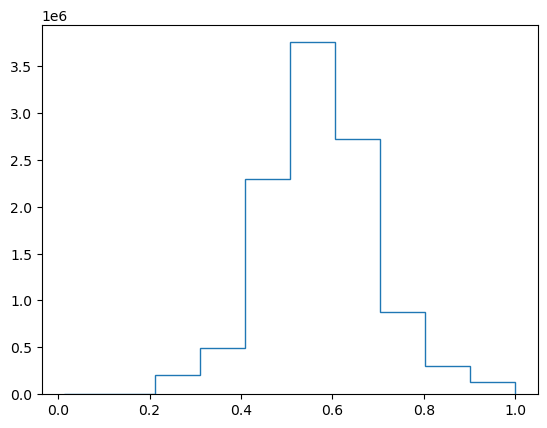

In [20]:
import matplotlib.pyplot as plt

counts, bins = np.histogram(similarities)
plt.stairs(counts, bins)

**Question 3.** Look at the shape of the distribution. Are these 4,600-odd compounds a diverse
collection, or a modest number of large analogue series? What does your answer imply for a model
trained on this set - which kinds of compound will it recognise, and which will it miss?

## 3. Strategy 1: looking for similar compounds in a big commercial catalogue

The first strategy needs no model at all and rests on the **similar property principle**: molecules
that look alike tend to behave alike. For every compound in the Asinex catalogue we compute the
similarity against all 4,640 known MDM2 binders and keep the compound if it resembles any of them
closely enough.

Two details in the cells below deserve attention. The cut-off of 0.8 is a choice, not a law - it is
the usual rule of thumb for this kind of path-based fingerprint, and it decides how many compounds
you end up buying. The condition is also written as `0.8 < s < 1.0`: the upper bound deliberately
throws away compounds that are *identical* to a known active, since a compound already in ChEMBL is
not a new candidate.

Before we start, though, it is worth asking whether all 646,891 compounds deserve the effort.

### 3.1 Narrowing the catalogue down first

A vendor catalogue is assembled for general screening, not for your target, and a large part of it
cannot possibly inhibit this particular interaction. Recall from notebook 1 what the MDM2 cleft
looks like: a deep hydrophobic groove that needs **three** bulky apolar groups pushed into it. A
compound of 250 Da with two polar substituents has nowhere near enough mass or greasiness to do
that, however favourable its fingerprint similarity happens to look.

That intuition can be made quantitative, and the right place to take the numbers from is the set of
known binders that you have just downloaded. Their properties and those of the catalogue are strikingly different:

| | median molecular weight | median cLogP |
|---|---|---|
| the 4,642 known MDM2 binders | 559 Da | 5.8 |
| the Asinex catalogue | 387 Da | 3.3 |

So we apply a **property filter** before the expensive steps: keep a compound only if its molecular
weight lies between 450 and 750 Da and its cLogP is at least 3. Those bounds are not invented; they
are read off the distribution of the known actives, and they retain **89% of them** while discarding
**85% of the catalogue** - 98,000 compounds survive out of 646,891. The median of what remains is
492 Da and cLogP 4.7, much closer to the chemistry we are looking for.

This has three consequences, and only the first is about speed.

1. Everything downstream becomes about six times cheaper. The similarity search drops to under a
   minute and the support-vector prediction from about 40 minutes to about 6.
2. The screen becomes **more focussed**, not just faster: we are no longer asking a model to rank
   fragments that could never fill three subpockets.
3. The decoy set of section 4 is drawn from this filtered catalogue, which makes it
   **property-matched** to the actives. That matters more than it sounds - see the discussion there.

And one warning, which is the real lesson of this section. A filter is an assumption written in
code. Ours says "MDM2 inhibitors are heavy and greasy", and if that assumption is wrong you have
thrown away the answer before the screen even started.

**Question 4.** The best-known filter in medicinal chemistry is Lipinski's rule of five, which asks
for a molecular weight **below** 500 and a cLogP **below** 5. Compare that with the numbers in the
table above, and with the five clinical MDM2 inhibitors you will meet in notebook 5 (555 to 660 Da).
What fraction of the known MDM2 binders would a Lipinski filter reject? (It is 94% - verify it
yourself from the `best` dataframe.) What does that tell you about applying generic drug-likeness
rules to inhibitors of a protein-protein interaction?

In [21]:
# Download the Asinex library of March 11, 2025
#url = "https://raw.githubusercontent.com/UAMCAntwerpen/2040FBDBIC/master/assets/databases/notebook-4/asinex_11march2025.smi"
#lines = requests.get(url).text.split("\n")
#print(len(lines))

# The property window, taken from the known MDM2 binders (see the text above).
# Widen it and the screen gets slower; narrow it and you risk discarding real candidates.
MW_MIN = 450.0      # a compound has to be big enough to fill three subpockets
MW_MAX = 750.0      # above this we are no longer looking at small molecules
CLOGP_MIN = 3.0     # the p53 cleft is hydrophobic

asinex_smiles = []
asinex_id = []
asinex_fp = []
asinex_npfp = []
n_rejected = 0      # how many compounds the property filter removes

with open("assets/databases/notebook-4/asinex_11march2025.smi", "r") as f: total_lines = sum(1 for _ in f)

with open("assets/databases/notebook-4/asinex_11march2025.smi", "r") as f:
    for LINE in tqdm(f, total=total_lines, desc="Processing SMILES"):
        LINE = LINE.strip()
        if LINE == "": continue

        FIELDS = LINE.split()
        if len(FIELDS) != 2: continue

        mol = Chem.MolFromSmiles(FIELDS[0])
        if mol is None: continue

        # Property filter: skip whatever cannot plausibly bind in the MDM2 cleft.
        # This is done before the fingerprint, because it is the cheap test.
        mw = Descriptors.MolWt(mol)
        if mw < MW_MIN or mw > MW_MAX:
            n_rejected += 1
            continue
        if Descriptors.MolLogP(mol) < CLOGP_MIN:
            n_rejected += 1
            continue

        fp = rdkgen.GetFingerprint(mol)

        np_fp = np.zeros((0,), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, np_fp)

        asinex_smiles.append(FIELDS[0])
        asinex_id.append(FIELDS[1])
        asinex_fp.append(fp)
        asinex_npfp.append(np_fp)

print(f"{len(asinex_smiles)} compounds kept, {n_rejected} rejected by the property filter")
print(f"that is {100.0 * len(asinex_smiles) / (len(asinex_smiles) + n_rejected):.1f} % of the catalogue")

Processing SMILES:   0%|          | 0/646891 [00:00<?, ?it/s]

98000 compounds kept, 548891 rejected by the property filter
that is 15.1 % of the catalogue


In [22]:
total = len(asinex_fp) * len(chembl_fp)

SIMILARITY_HITS_fp = []
SIMILARITY_HITS_idx = []

CUTOFF = 0.8

for idx, fp in enumerate(tqdm(asinex_fp, desc="Bulk similarity")):
    sims = DataStructs.BulkTanimotoSimilarity(fp, chembl_fp)
    if any(CUTOFF < s < 1.0 for s in sims):
        SIMILARITY_HITS_fp.append(fp)
        SIMILARITY_HITS_idx.append(idx)

Bulk similarity:   0%|          | 0/98000 [00:00<?, ?it/s]

**Question 5.** Re-run this search with a cut-off of 0.7 and of 0.9 (the search takes a few
minutes each time, so do this one only if you have time). How quickly does the number of hits
change? Now the conceptual question: a compound that is 0.79 similar to a known active is rejected
while one at 0.81 is kept. Is there anything chemically special about that boundary?

In [23]:
print(len(SIMILARITY_HITS_fp))

478


## 4. Strategy 2: classification models applied to the catalogue

The second strategy asks a model to judge the catalogue. Training a classifier needs actives **and**
inactives, and here we run into the standard problem of virtual screening: nobody publishes the
compounds that did not work, so there is no list of confirmed MDM2 inactives.

The usual way out is a **decoy set**: assume that compounds picked at random from a large catalogue
are inactive. For a target with few actives that assumption is nearly always right, and it is what
the cell below does.

Because of the filter in section 3, those decoys are now **property-matched** to the actives: both
groups have a median weight around 500 Da and a cLogP around 5. That is worth more than it looks.
Had we drawn the decoys from the unfiltered catalogue, with a median of 387 Da, the classifier could
have reached a high accuracy simply by learning "heavy means active" - it would have been a very
good molecular-weight detector and a useless MDM2 model. Forcing the decoys into the same property
range takes that shortcut away, so the accuracies you are about to see are lower than they would
otherwise have been, and more honest. But it is an assumption, and it has a consequence worth remembering - the model
is not learning "active versus inactive", it is learning "resembles a published MDM2 paper versus
resembles a random catalogue compound". Those are not the same thing.

### 4.1 A random forest

In [24]:
# For this we assume that the CHEMBL_HITS contains all actives
# We need to create a decoy set with inactives: we can take a random sample from the Asinex for this
import random

decoy_npfp = [asinex_npfp[random.randint(0, len(asinex_npfp) - 1)] for _ in range(len(chembl_npfp))]
print(len(decoy_npfp))

4642


**Question 6.** Suppose that one catalogue compound in every thousand is in fact a weak MDM2
binder. Roughly how many true actives are then hiding in this decoy set of 4,600-odd compounds, and what
does that do to the accuracy your model reports? Is the problem worse for the *accuracy* or for the
*precision* of the model?

In [25]:
# Now we need to prepare the data for model building.
# We need a list with fps, and a second list with the activity class (1 = active, 0 = inactive)
npfp = []
activities = []
for i in chembl_npfp:
    npfp.append(i)
    activities.append(1)
for i in decoy_npfp:
    npfp.append(i)
    activities.append(0)

print(len(activities), len(npfp))

9284 9284


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

act_train, act_test, fps_train, fps_test = train_test_split(activities, npfp, test_size=0.3)
model = RandomForestClassifier(max_depth=2)
model.fit(fps_train, act_train)

,n_estimators,100
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

prediction = model.predict(fps_test)
print(accuracy_score(act_test, prediction))

0.9221105527638191


**Question 7.** This accuracy is computed on a test set that contains about as many actives as
inactives, which is nothing like the catalogue the model will be applied to, where actives are
perhaps one in a thousand. What would the accuracy of a model that simply answered "inactive" to
everything be, on the test set and on the catalogue? Which number would you report in a paper?

In [28]:
# Apply the model to the entire asinex library 
prediction = model.predict(asinex_npfp)

RF_HITS_fp = []
RF_HITS_idx = []

for i in range(len(prediction)):
    if prediction[i] == 1:
        RF_HITS_fp.append(asinex_fp[i])
        RF_HITS_idx.append(i)

print(len(RF_HITS_fp))

4365


### 4.2 A more complicated model: a neural network

The same data, a more flexible model. Note that this pipeline first standardises the features and
then fits a network with two hidden layers, and that it is judged with the ROC AUC rather than the
accuracy.

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=500, random_state=42))
])

act_train, act_test, fps_train, fps_test = train_test_split(activities, npfp, test_size=0.3)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=500,
                          random_state=42,
                          activation='tanh',
                          alpha=0.005, 
                          batch_size=64,
                          hidden_layer_sizes=(512, 256),
                          learning_rate_init=0.001))])
model.fit(fps_train, act_train)
predictions = model.predict(fps_test)
print(roc_auc_score(act_test, predictions))

0.9928603097354257


In [30]:
# Apply the model to the entire asinex library 
prediction = model.predict(asinex_npfp)

NN_HITS_fp = []
NN_HITS_idx = []

for i in range(len(prediction)):
    if prediction[i] == 1:
        NN_HITS_fp.append(asinex_fp[i])
        NN_HITS_idx.append(i)

print(len(NN_HITS_fp))

953


### 4.3 A support-vector model

A support-vector classifier with an RBF kernel. It is the most expensive of the three by a wide
margin: the fit takes a couple of minutes, and **applying it to all 646,891 catalogue compounds
takes around 40 minutes**, because every compound has to be compared with thousands of support
vectors. Start the cell and read on.

In [31]:
from sklearn.svm import SVC

# Split data
act_train, act_test, fps_train, fps_test = train_test_split(activities, npfp, test_size=0.3)

# Create model
model = SVC(
    kernel="rbf",        # radial basis function (default)
    C=1.0,               # regularization
    gamma="scale",       # kernel coefficient
    probability=True,    # needed for ROC AUC
    random_state=42
)

# Train
model.fit(fps_train, act_train)
predictions = model.predict(fps_test)
print(roc_auc_score(act_test, predictions))

0.9959826934102148


In [32]:
# Apply the model to the entire asinex library 
prediction = model.predict(asinex_npfp)

SVC_HITS_fp = []
SVC_HITS_idx = []

for i in range(len(prediction)):
    if prediction[i] == 1:
        SVC_HITS_fp.append(asinex_fp[i])
        SVC_HITS_idx.append(i)

print(len(SVC_HITS_fp))

97


**Question 8.** You now have three models, all of which looked good on their test set - accuracy
0.94 for the forest, ROC AUC above 0.99 for the network and the support-vector model - and their hit
lists differ by more than an order of magnitude. Which of the three would you believe? What
experiment, computational or real, would settle it?

## 5. Combining the hit lists and generating 3D structures

Four strategies have each produced a list of candidates. Taking the **union** of the four - rather
than the intersection - is a deliberate choice: at this stage we would rather look at a compound
that only one method liked than throw it away, because each method is blind in a different way.

The compounds are then given a three-dimensional structure. This is not cosmetic: notebook 5 matches
molecules against a pharmacophore, which is a three-dimensional object, so the database has to carry
coordinates. `EmbedMolecule()` with ETKDGv3 generates **one** conformation per molecule and MMFF
cleans it up. One conformation per molecule is a compromise that notebook 5 will have to live with -
and will come back to.

In [33]:
# First make sure that we remove duplicates
idx_set = set(SIMILARITY_HITS_idx) | set(RF_HITS_idx) | set(NN_HITS_idx) | set(SVC_HITS_idx)
print(len(idx_set))
print(len(SIMILARITY_HITS_idx) + len(RF_HITS_idx) + len(NN_HITS_idx) + len(SVC_HITS_idx))

5327
5893


**Question 9.** The union of the four hit lists is larger than any single list; the intersection
would be much smaller than all of them. Which would you buy if your budget allowed 100 compounds,
and which if it allowed 10,000? In notebook 5 the pharmacophore will be applied to this union as a
second, independent filter - does that change your answer?

In [34]:
mols = []
for i in idx_set:
    smiles = asinex_smiles[i]
    code = asinex_id[i]
    mol = Chem.MolFromSmiles(smiles)
    mol.SetProp("_Name", code)
    mol_h = Chem.AddHs(mol)
    status = AllChem.EmbedMolecule(mol_h, AllChem.ETKDGv3())
    if status == 0:
        # Optional geometry optimization
        AllChem.MMFFOptimizeMolecule(mol_h)
        mols.append(mol_h)

In [35]:
# Write to sdf
writer = Chem.SDWriter("scratch/hits_from_classification_models.sdf")

# Write molecules
for mol in mols:
    if mol is not None: writer.write(mol)

# Close file
writer.close()

## 6. Finished?

You have built a focussed library: starting from 646,891 purchasable compounds and everything the
literature knows about MDM2, a property filter and four ligand-based strategies have
selected a few thousand candidates - about 5,300 in the run above - each with a three-dimensional
structure, in `scratch/hits_from_classification_models.sdf`.

It is worth being clear about what that file is and is not. Every compound in it resembles something
that has been published as an MDM2 binder, or is recognised as such by a model trained on those
publications. Not one of them has been looked at by a method that knows the *shape of the binding
site* - the protein structure you studied in notebook 1 has played no part in this notebook at all.
That is the gap the next notebook closes.

For those that are interested in machine learning for drug discovery, this paper provides an
excellent review of the current state-of-the-art on this topic:

- <a href="assets/pdf/Machine-learning-in-drug-discovery-a-review.pdf" download>Machine learning in drug discovery: a review</a>

When finished, it is time to move to the fifth notebook of this course. In this notebook, you will
translate the three-dimensional structure of the MDM2-p53 complex into a pharmacophore, and use it
to refine the compound database that you have just built:

- [Notebook 5: Pharmacophore searching](Notebook-5-pharmacophore-searching.ipynb)